# Calibrating the test before trusting it

A verdict on round 4 of a weighted mid-training procedure was published, withdrawn,
reinstated, and then attacked for two days by ten adversarial passes. Its direction
survived every one. Its stated strength survived none of them, and the reason took
a long time to find: nobody had ever asked whether the tests being used could
distinguish an effect from nothing.

They can be asked directly. Splitting one checkpoint's ten generation seeds into
disjoint fours produces contrasts that are null by construction — same weights,
same contexts, same code, different randomness. There are 1575 of them. Running
every candidate test on all 1575 says exactly how large each test reads when the
answer is known to be zero.

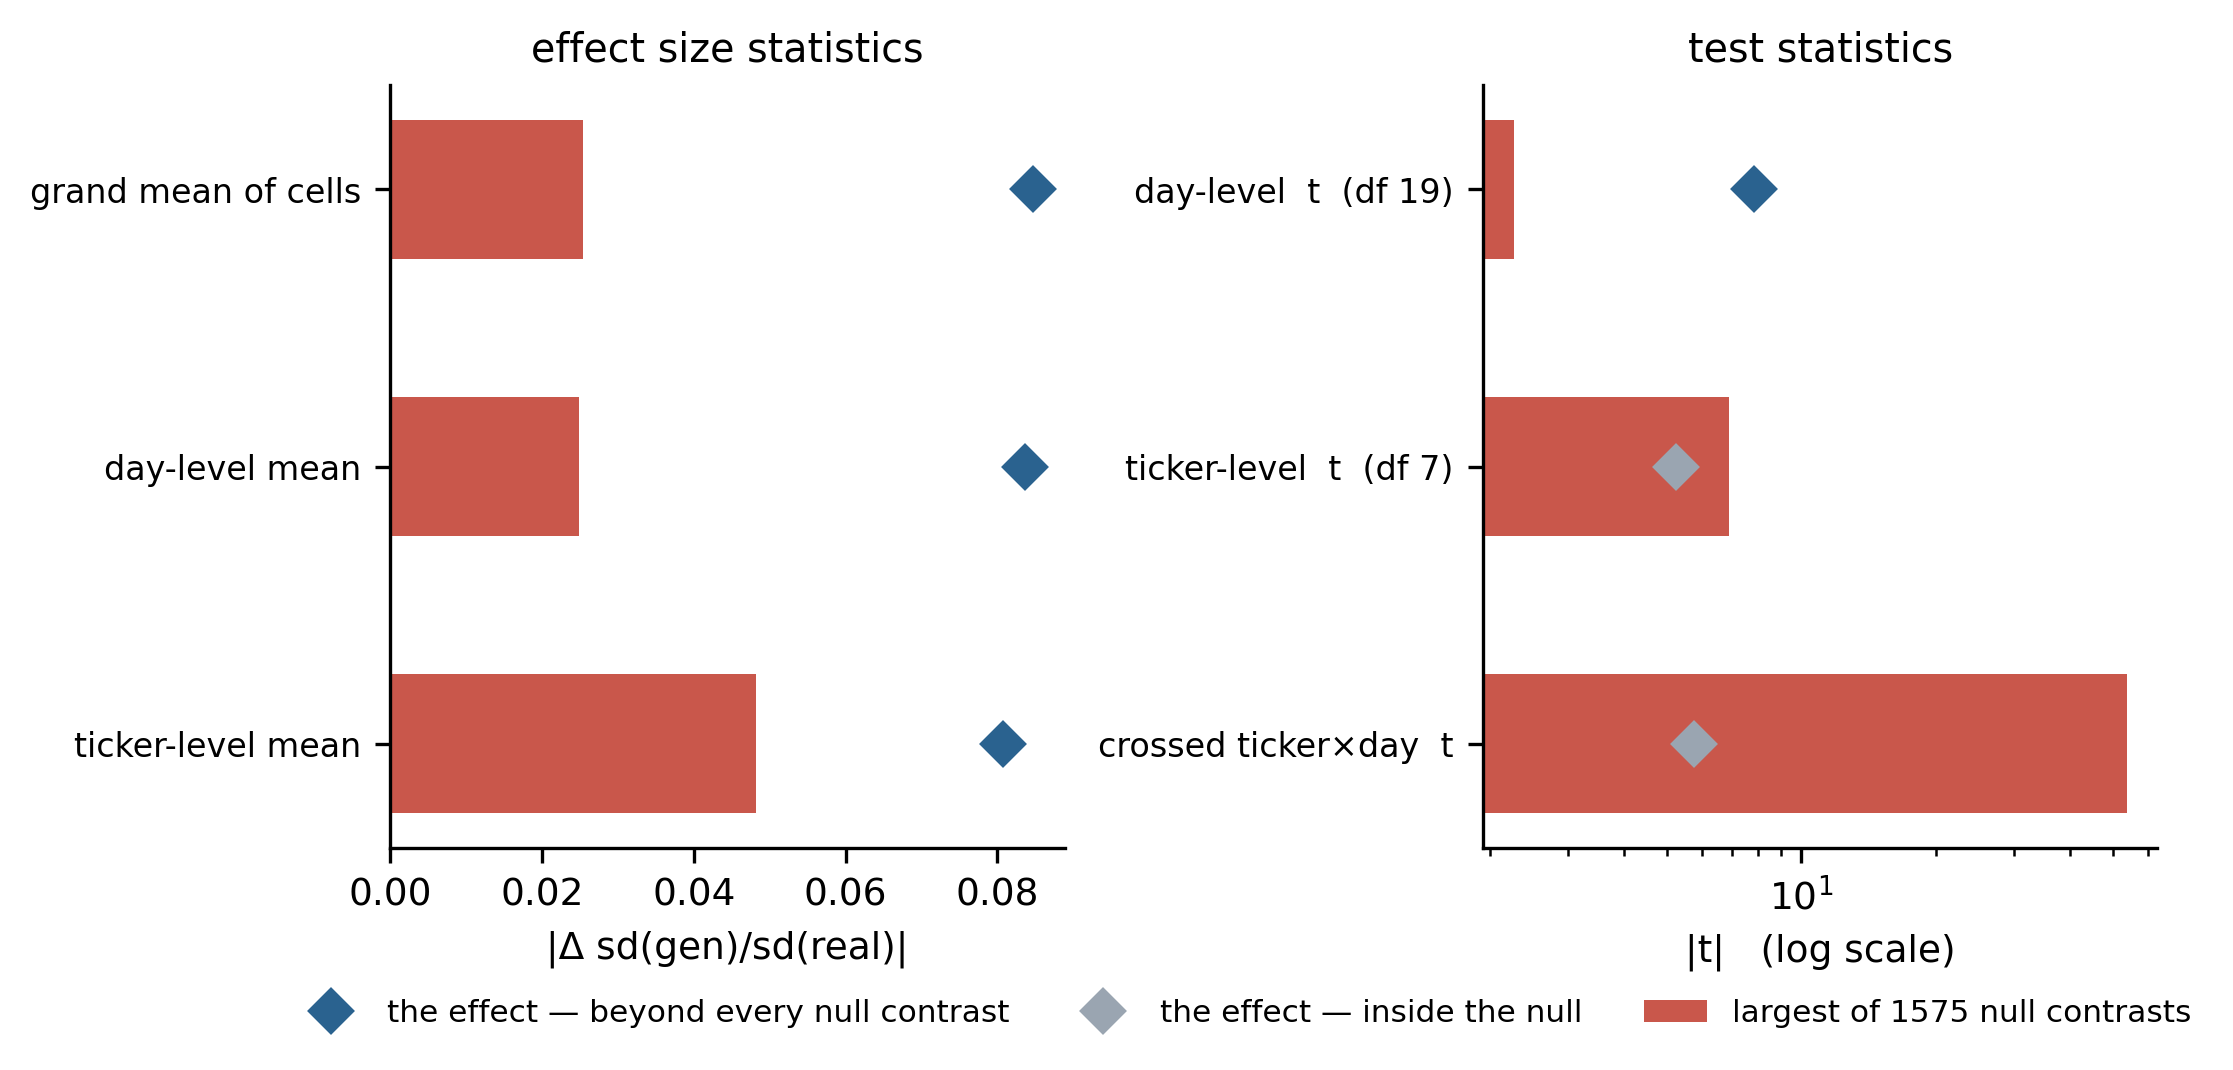

In [1]:
# n1_calibration.png

Red is the largest value each statistic reaches
across 1575 contrasts that contain no effect at all. Blue diamonds are the round-4
effect. On the three effect-size statistics the effect clears every null contrast.
On the test statistics the picture is different: the **ticker-level t reaches
6.87 on null data** — larger than the
effect's own −5.25 — and the **crossed ticker×day model reaches
53.7**, failing to produce a positive
variance at all on 24 of
1575. Both are unusable as tests. The day-level t peaks at
2.26, i.e. it is conservative — the
opposite of what a day of analytic argument had concluded.

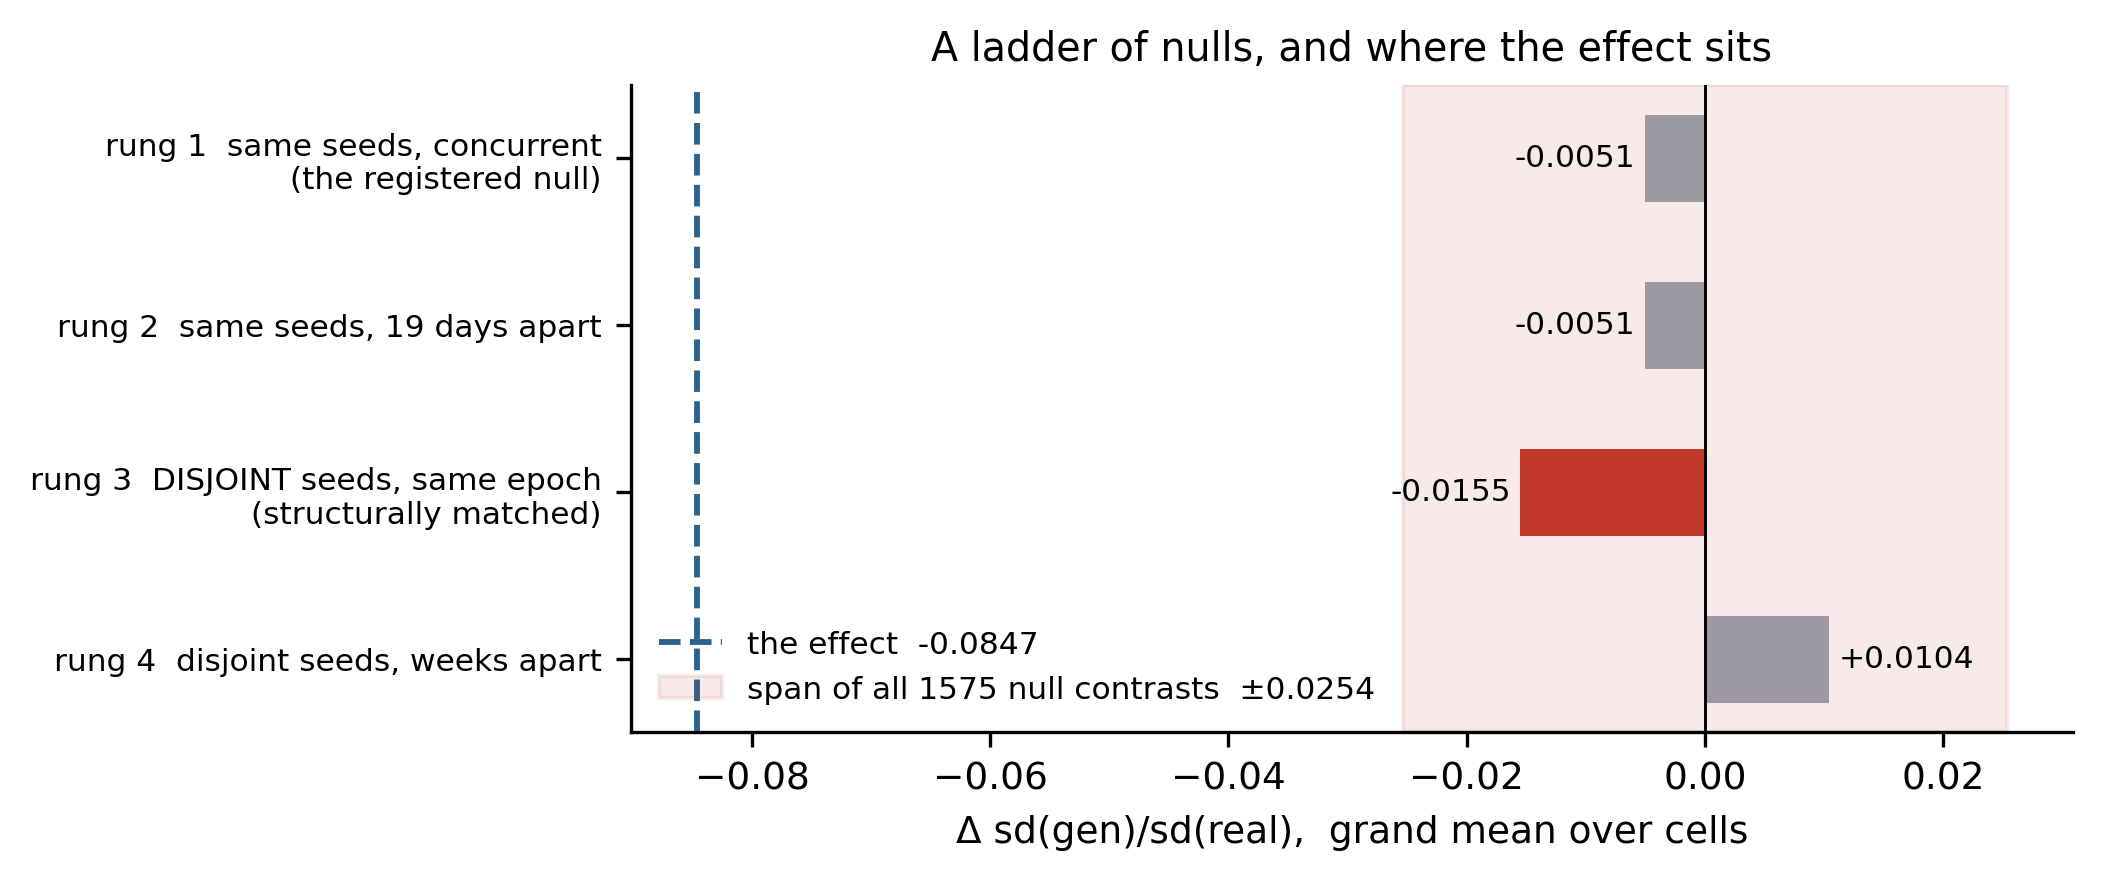

In [3]:
# n2_null_ladder.png

The effect differs from its comparison arm in the
checkpoint **and** in the generation seeds, and both were generated the same day.
Only rung 3 matches that: it holds the checkpoint fixed and varies the seeds, in one
epoch. The registered null (rung 1) holds the seeds fixed as well, so it cancels a
source of variation the effect actually carries —
-0.0051 against rung 3's
-0.0155, a factor of
3.1.

The correction runs the other way from the usual: **the registered null was too
tight, and replacing it makes the effect stronger**, because the seed-disjoint null
spread (0.0096) is smaller than the naive day-level standard error (0.0107).

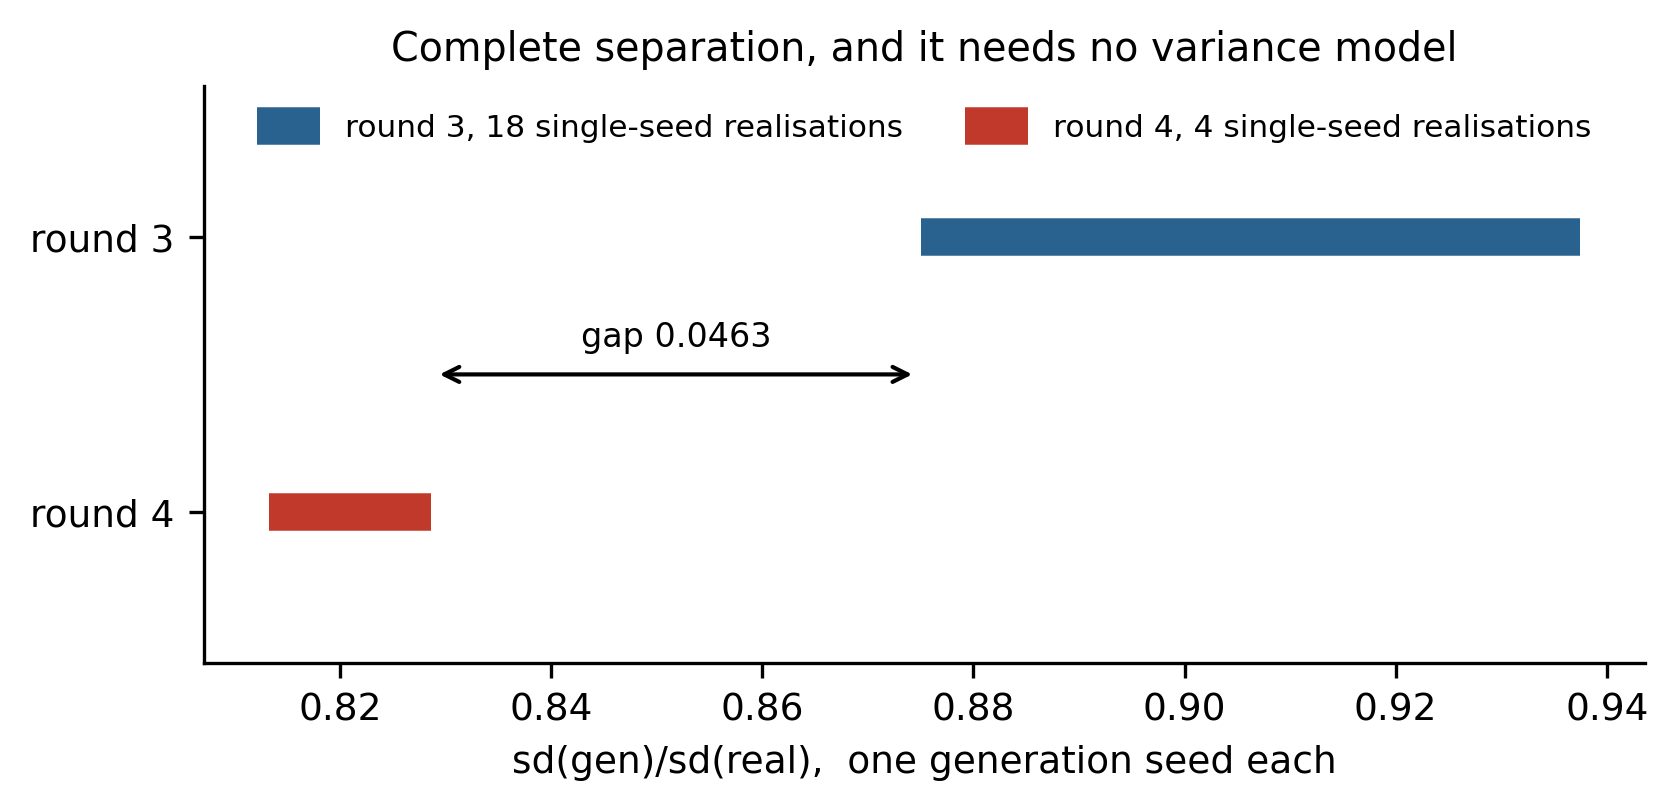

In [5]:
# n3_separation.png

Every one of round 3's
18 single-seed realisations sits above every one of round 4's
4, separated by 0.0463. The exact two-sided rank test gives

$$ p \;=\; \frac{2}{\binom{22}{4}} \;=\; \frac{2}{7315} \;=\; 0.000273 $$

with no degrees of freedom to argue about, no independence assumption, and no
variance component. It is the strongest statement available here and it had never
been computed — the entire two days of dispute was over parametric tests that this
one sidesteps.

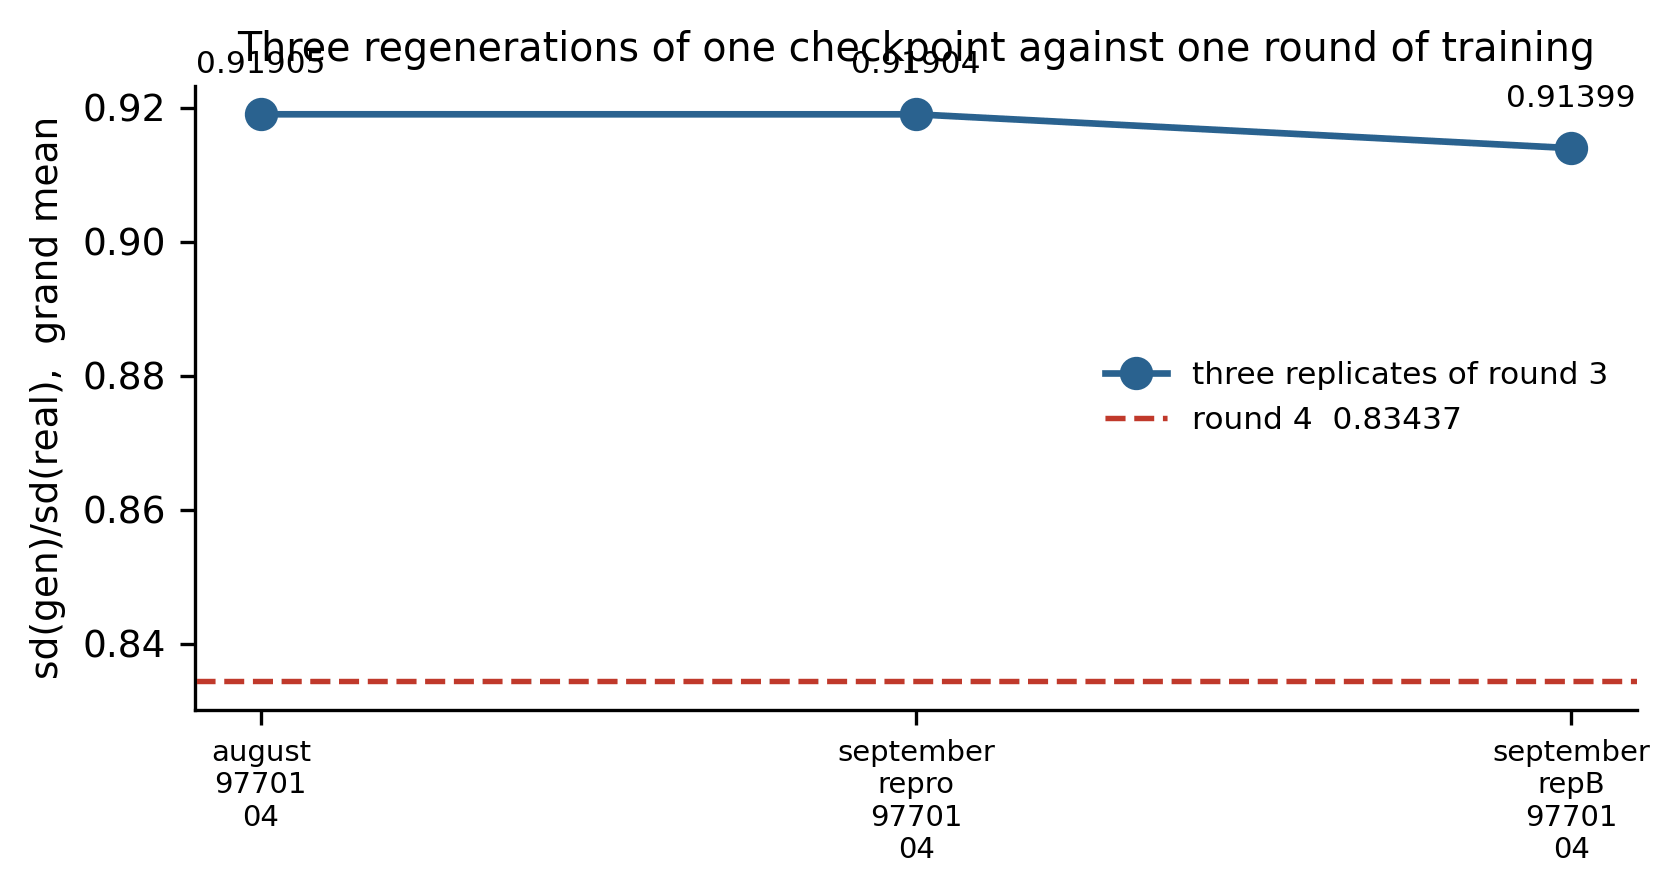

In [7]:
# n4_replicates.png

Round 3 regenerated three times — August, and twice
in September — agrees to a spread of 0.0051 (sd 0.0029). Round 4
sits -0.0830 away, about
16× that spread.

One correction to an earlier reading of this: the three replicates were said to
disagree in sign, which would have been evidence that the run-order drift is not
systematic. They do not — the three levels are monotone. The conclusion holds; that
particular argument for it does not.

## What the calibration changes

Two days of argument turned on which unit of analysis is legitimate. The ticker-level
test was accused of ignoring that all eight tickers share the same twenty trading
days; the day-level test was then accused of discarding the ticker component, since
a common day shock cancels in a paired difference; the crossed model was proposed as
the resolution. All three arguments were analytic, and all three could have been
settled empirically in an afternoon.

Let $R_{a}(t,d)$ be the scored ratio for arm $a$, ticker $t$, day $d$. Splitting one
checkpoint's ten generation seeds $\mathcal{S}$ into disjoint fours $A \sqcup B$
gives

$$ N_{A,B}(t,d) \;=\; R_{B}(t,d) - R_{A}(t,d) $$

which has expectation zero **by construction** — identical weights, identical frozen
contexts, identical code; only the generator's randomness differs. There are
$\binom{10}{4}\binom{6}{4}/2 = 1575$ such contrasts. Applying a candidate test $T$ to
all of them gives its null distribution without assuming anything about
independence, degrees of freedom, or variance components.

The result is that two of the three candidate tests are unusable:

| test | largest $|T|$ on null data | verdict |
|---|---:|---|
| ticker-level $t$, df 7 | 6.87 | fires harder on nothing than the effect does on something |
| crossed ticker×day $t$ | 53.65 | Satterthwaite df on the effect is 3.24, and the fit produced no positive variance at all on 42 of 1575 null contrasts. A $t$ of 53.65 on df ≈ 3 is not a large effect, it is a variance estimate that collapsed; the number must never be quoted without its df. |
| day-level $t$, df 19 | 2.26 | conservative |

The day-level test — the one the analytic argument had condemned as
anti-conservative — is the one that survives, and it survives by being *too*
cautious rather than too bold.

## The honest numbers

| statistic | effect | rung-3 null sd | z vs the correct null | conservative z |
|---|---:|---:|---:|---:|
| grand mean of cells | -0.0847 | 0.0096 | **-8.83** | -6.95 |
| day-level mean | -0.0836 | 0.0093 | -8.95 | -6.82 |
| ticker-level mean | -0.0808 | 0.0195 | -4.15 | -3.48 |

"Conservative" adds the same-seed regeneration component on top of the seed-disjoint
null. Charging the null's own sampling error at the upper end of its χ² interval
(df 9) still leaves -4.84 on the grand
mean.

The effect exceeds **every one** of the 1575 seed-disjoint null contrasts, whose
largest magnitude is 0.0254 against an effect of
0.0847.

**Negative control.** Round 4 against round 2 — two arms separated by two rounds of
training in the same direction — sits *inside* the rung-3 null on every statistic
(grand mean -0.0081, p ≈ 0.41). The
ladder is not manufacturing verdicts out of any pair of arms handed to it.

## The seed variance component, measured rather than assumed

Ten single-seed realisations of one checkpoint give sd
0.01397 on 9 degrees of freedom. Three independent
routes agree on what that implies for a four-seed arm: the prediction
0.00699, the observed spread over all 210 quadruples
0.00529, and the randomisation sd of a
disjoint 4-vs-4 contrast 0.00959. Agreement to
a few percent across three constructions is the check that this component is real and
correctly sized.

## What still does not stand

The registered CRPS result for round 2 → round 3 remains unsupported, and the
reason is a null that existed and was not applied: regenerating round 3 at the same
seeds moves `fair_crps` by +1.339e−06 (t +2.09) against a claimed gain of
−2.670e−06 (t −2.70). The null is half the effect and nearly passes the same test;
two-arm regeneration noise accounts for 91% of the effect's cross-ticker spread.

The split-half "replication" reported earlier carries no information: **all 92,378
balanced splits of the twenty days pass at p < 0.05**, so the test cannot fail. The
odd/even split chosen sits at the 7.7th percentile of discrepancy, and a
chronological split instead shows the effect nearly doubling across the month
(−0.063 in the first ten days, −0.104 in the last ten).

And the causal attribution is still open. Round 4 is round 3's weights plus another
4800 steps, so *the reweighting overshot* and *more mid-training degrades this* are
not separated by anything measured here. A uniform-weight continuation matched on
every other axis is running as this is written.

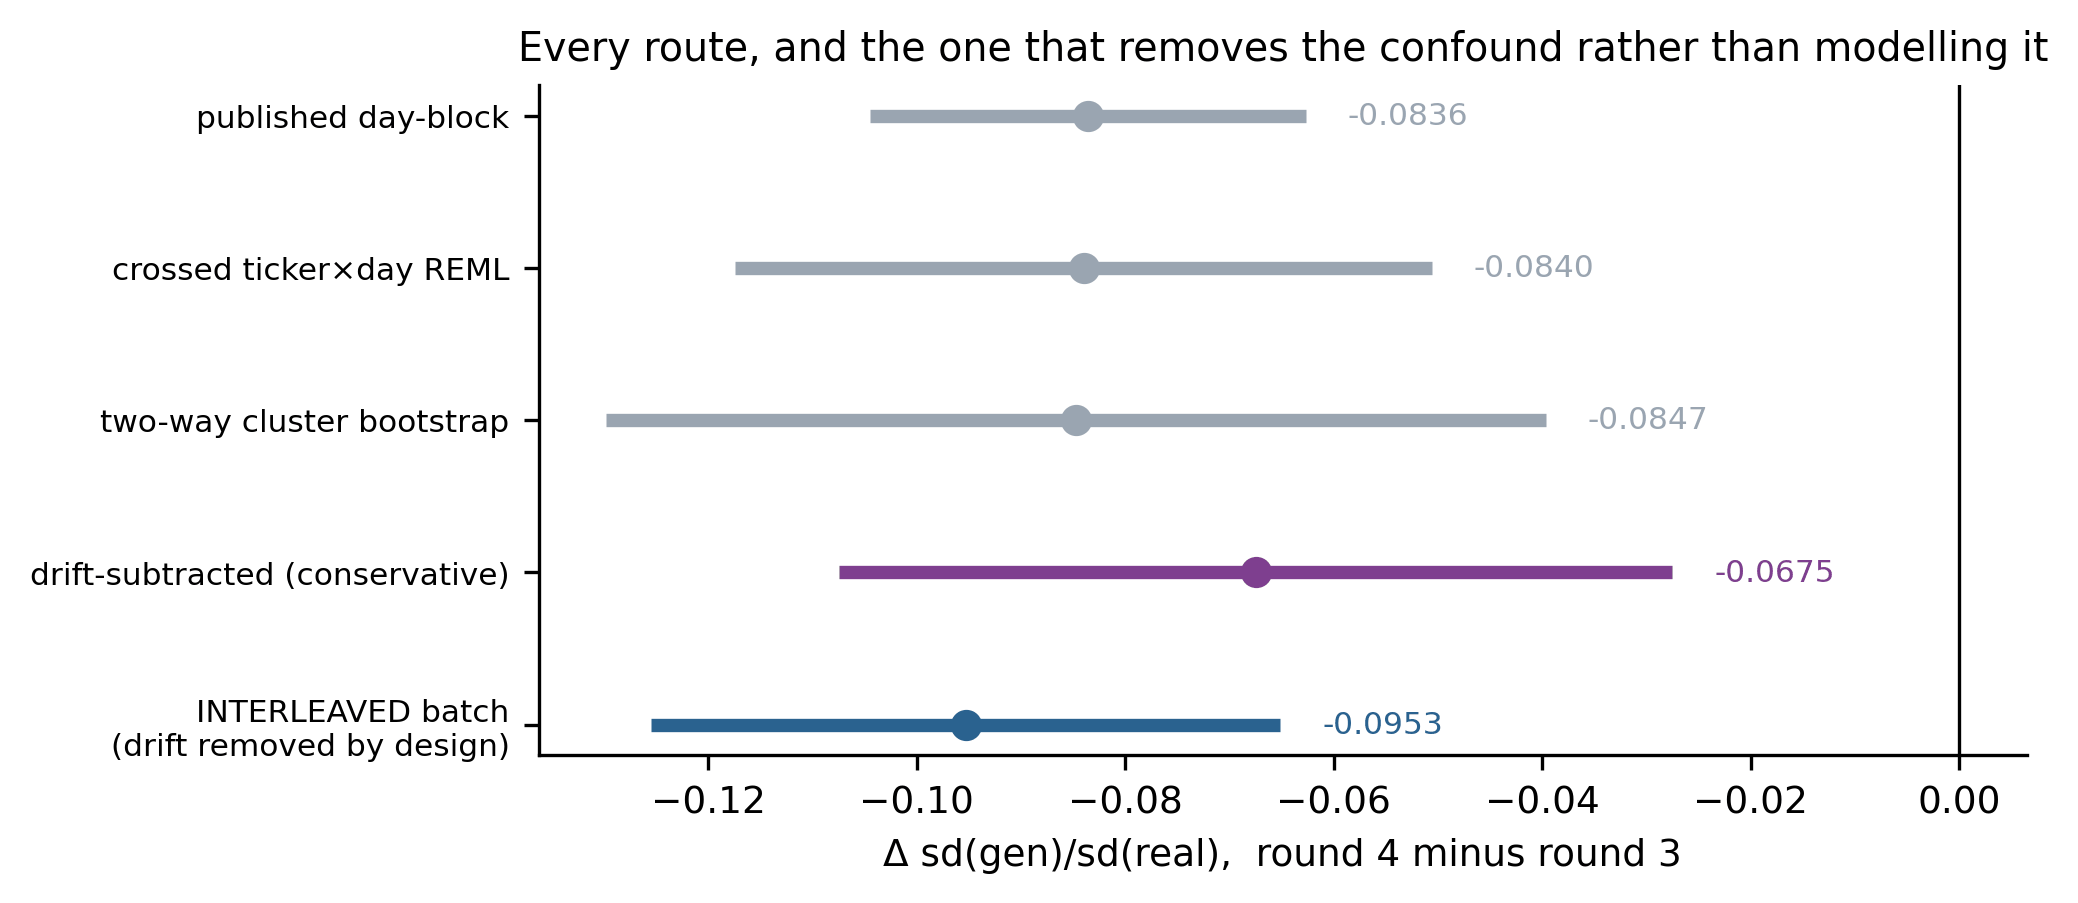

In [11]:
# n5_interleaved.png

The run-order confound was handled two ways. Subtracting
an estimated drift moves the point estimate **toward** zero, to −0.0675. Removing the
confound by construction — both arms at the same seeds, back-to-back on the same card,
order fixed by a recorded draw — puts it at **−0.0953 (se 0.0154, t −6.17, p 4.6e−4,
8/8 tickers negative)**, further from zero. Its own null, the interleaved round 3
against an independent round-3 replication, is +0.0029 (p 0.81).

So the drift correction is conservative, and the experiment built to test the
attribution does not support it. That is the shape a real effect makes and a run-order
artifact does not.

## The estimator was tested against known answers

Simulating the real missing-data structure with known variance components, 300
replicates each, the replaced day-block estimator has a standard error **23% too
small**, and its nominal 95% interval covers **88.5%**. The crossed model recovers the
components and covers 95.3%. That is measured, not argued — and it is what two days of
analytic dispute about degrees of freedom had been unable to settle.

One disagreement between passes is worth recording rather than smoothing over: on
Satterthwaite degrees of freedom, one route reported 35–44 and another 6.7. The
simulation adjudicates — coverage is correct at df ≈ 7 and would be substantially short
at 35–44 — and the reasoning agrees with it: eight ticker groups carry 39% of the
variance of the mean, and a denominator cannot hold more information than seven
between-group contrasts.

## Headline

```
point  −0.0675    se 0.0204    df 7    t −3.31    p 0.0129    95% CI [−0.1157, −0.0193]
```

the most conservative of the four routes: round 4 against the mean of three round-3
replications, two-way cluster bootstrap, run-level variance at its undeducted upper
bound, one step of run-order drift subtracted.

**Conditional on** one round-4 training run, scored against three round-3 regenerations,
over a single twenty-day window in January 2026 — inside which the effect itself drifts
at −0.0038/day, from −0.063 in the first ten days to −0.104 in the last ten. The
interval covers variation across tickers, days, cells and generation runs. It does
**not** cover variation across round-4 *training* runs, because there has only been
one, so it cannot separate "round 4 does this" from "this round-4 checkpoint does this".

## Where this leaves the two questions

**Does round 4 degrade the return distribution?** Yes, in sign and rough magnitude,
on every route (−0.06 to −0.10, all p < 0.05), reproduced on an independent batch with
the confound removed by design. What is withdrawn is `t = −7.84` and `df = 19`: the
honest strength is 3 to 4 standard errors on about 7 degrees of freedom.

**Does the mid-training work in the first place?** Not established on the metric the
line is named for. The round-2 → round-3 `fair_crps` gain has a replication null that
was sitting on disk unused, and that null is half the size of the gain and nearly
passes the same test.

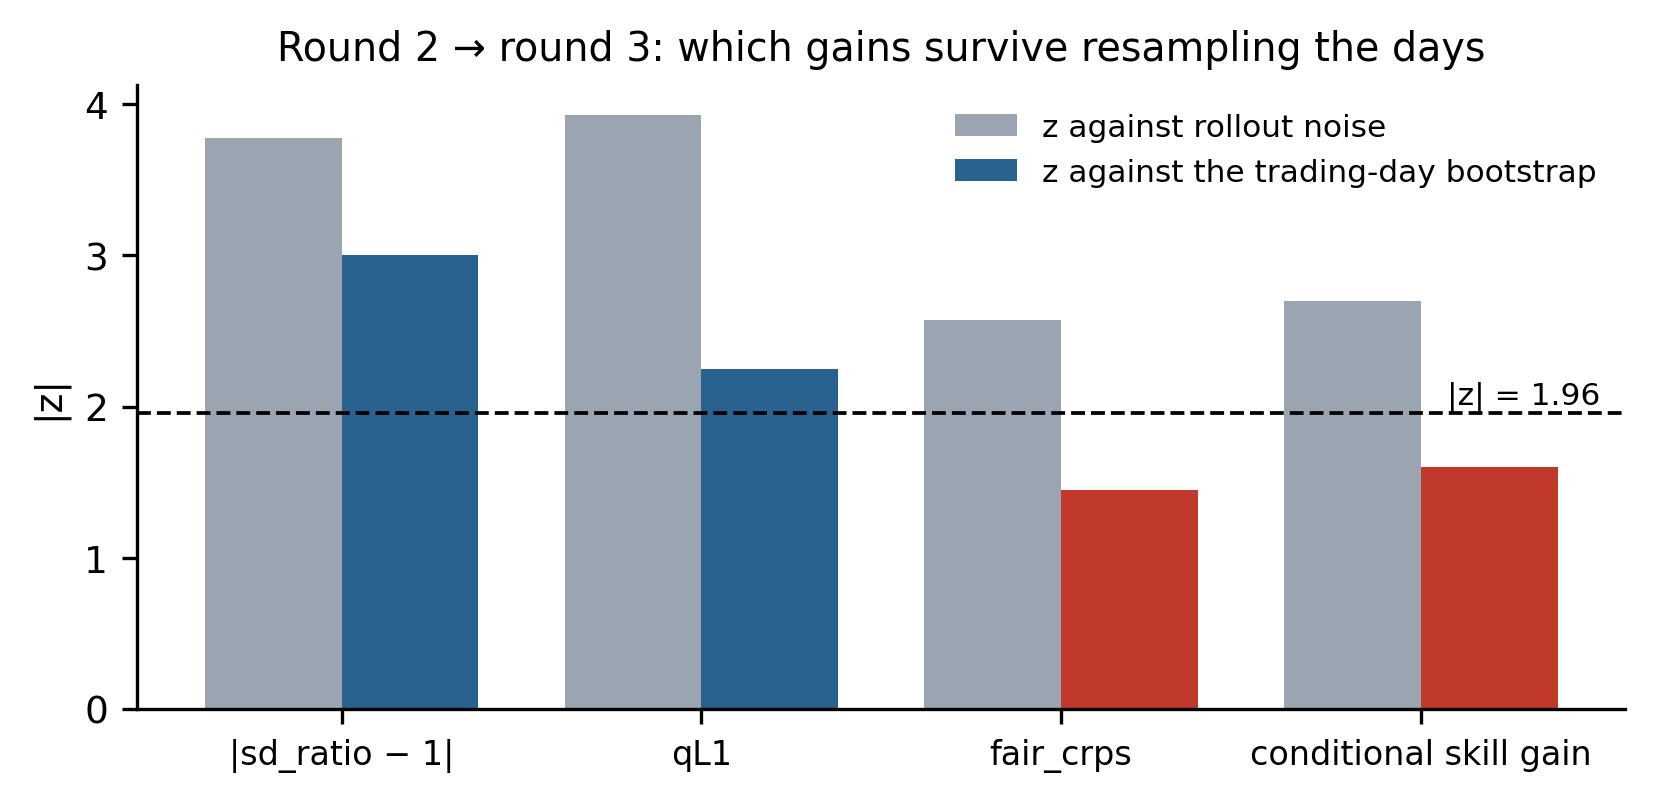

In [14]:
# n6_midtraining.png

Every gain clears rollout noise. Two clear the
trading-day bootstrap and two do not — and the two that do not include `fair_crps`,
the score this line is named for. All eight tickers are measured on the **same twenty
January sessions**, so the eight "independent replicates" are eight views of twenty
shared days; day noise (1.52e−06) turns out to exceed rollout noise (1.04e−06) for
CRPS, and it was the larger error bar all along.

## Two of the three registered metrics cannot see conditioning at all

This is provable rather than statistical. Permuting which real continuation belongs to
which context, within (ticker, day), leaves

$$ \max\left|\Delta\,\mathrm{qL1}
ight| = 0.0, \qquad
   \max\left|\Delta\,\mathrm{sd\_ratio}
ight| = 2.2	imes10^{-16} $$

because both are computed on samples flattened across contexts. A generator that
reproduced the unconditional return law and ignored the context entirely would score
`sd_ratio = 1` and `qL1 = 0` — a perfect score with zero conditional skill.

Only `fair_crps` pairs each ensemble with its own observation, and it does see the
conditioning: both arms score **13.07%** (round 2) and **15.71%** (round 3) below their
own context-blind counterparts, and both beat a within-day climatology. **The models
are genuinely conditional.** That is a statement about each checkpoint. The *gain* in
conditional skill between them, +2.65 pp, does not survive the day bootstrap.

## A correction to an earlier reading in this same line of work

An earlier pass concluded that the round-2 → round-3 CRPS gain failed because a
replication null (regenerating round 3 at the same seeds) came to +1.339e−06 with
t +2.09 — half the effect, nearly passing the same test. **That reasoning was wrong,
in three ways, and the conclusion happened to be right for a different reason.**

Building 185 do-nothing contrasts from disjoint splits of one round's own seed pool
puts that single null at **1.29 SD** of its own null distribution, with **24% of
do-nothing contrasts further from zero**; a do-nothing contrast reaches |t| ≥ 2 in
**7.0%** of draws, exactly what a valid t-test should give. The `sqrt(2)` inflation
applied to it double-counted, since 1.812e−06 was already the cross-ticker sd of a
two-arm difference. And using it as a bias correction makes the claim *stronger*
(t −2.70 → −4.05), because every null mean is positive while the effect is negative.

What actually removes the result is the trading-day bootstrap, which no pass had run
on the aggregate.

The general lesson, and it recurred three times in two days: **a single null contrast
is not a noise floor.** Its own t exceeds 2 about 7% of the time. The floor is the
*distribution* of nulls — 185 here, 1575 for the round-4 comparison — and the effect's
position within it.

## Where the mid-training stands

| claim | verdict |
|---|---|
| dispersion moves toward the data's | **established**, z −3.00 (p 0.003) under the day bootstrap |
| standardised quantile shape improves | **established**, z −2.25 (p 0.024) |
| `fair_crps` improves | **not established** — z −1.45 (p 0.147) |
| conditional skill *rises* | **not established** — z +1.60 (p 0.110) |
| both models are conditional at all | **established**, 13–16% below context-blind, z ≈ 13 and 16 |
| the gain is just a rescaling | **rejected** — matching dispersion reproduces 13.6% of it |
| dose-response across checkpoints | **absent** — 0/6 tickers monotone on any metric; qL1 wanders 0.0389 between adjacent checkpoints against an endpoint gain of 0.0306 |

Unestablished, with no data on disk that could settle it: there is **one training run
per round**. Every null here varies rollouts or days; none varies the fine-tuning run.
One twenty-session window, eight large-cap names, one horizon.


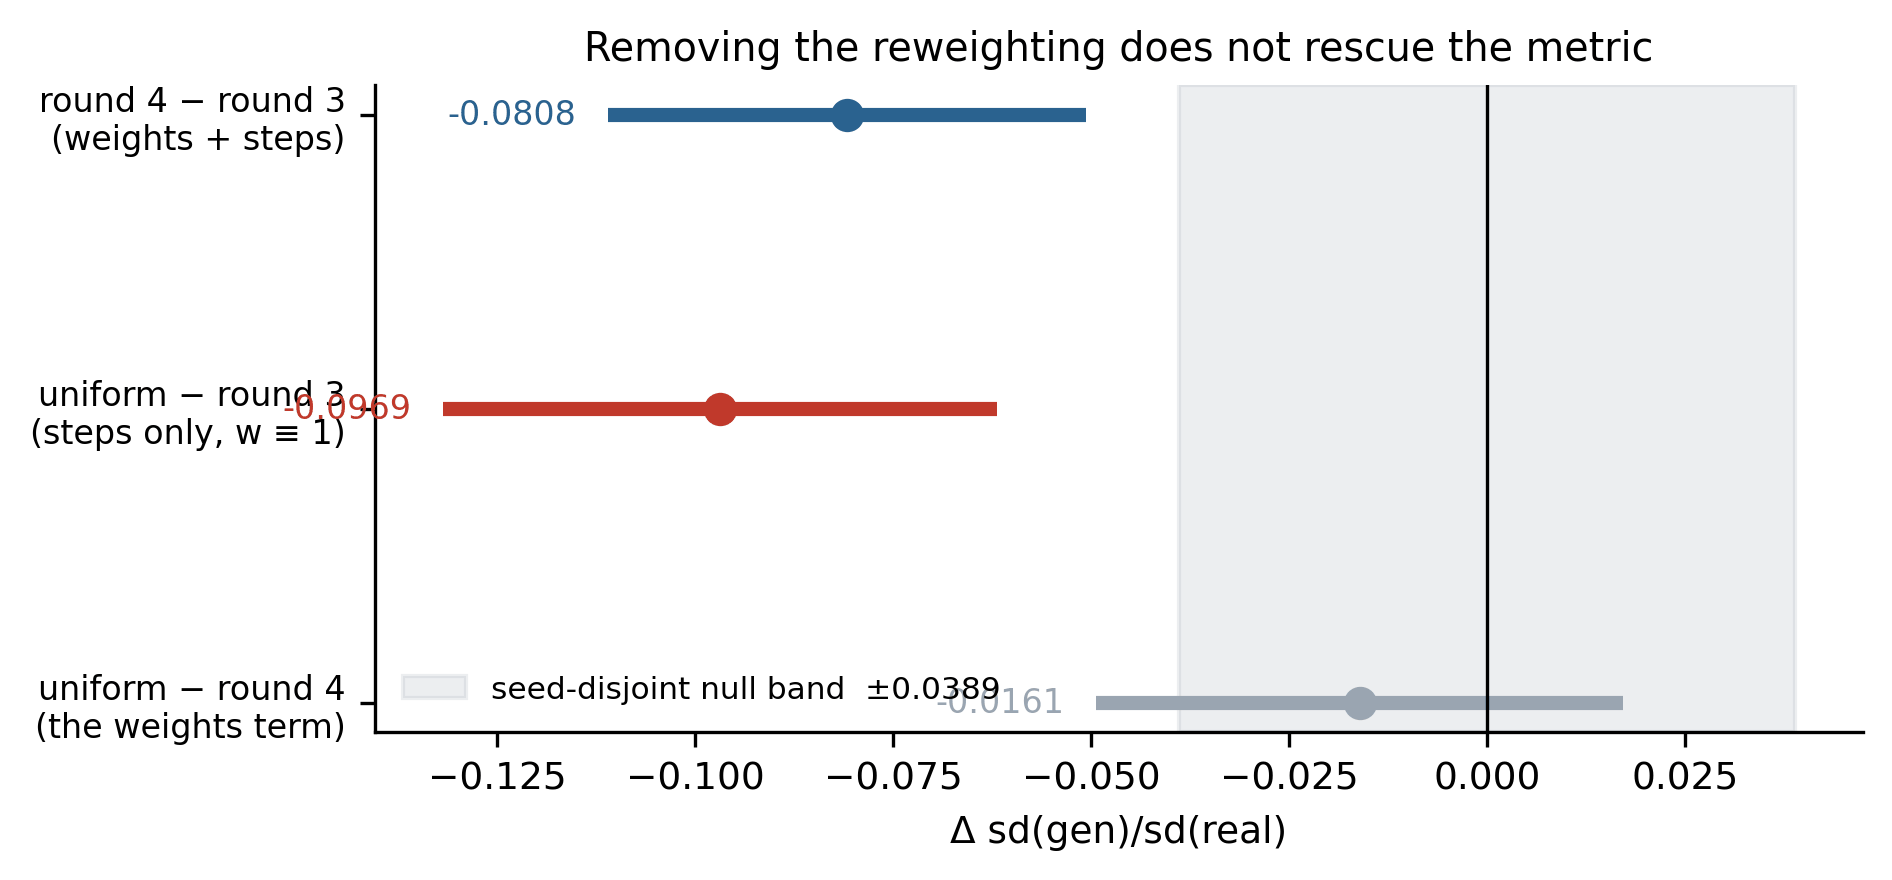

In [17]:
# n7_attribution.png

The uniform-weight arm carries round 3's weights, sets
every importance weight to exactly 1, and runs the same 4800 steps with all fourteen other
axes matched to round 4. It isolates the step-count term.

It degrades the metric by **-0.0969** — *more*
than round 4's -0.0808, on 8/8 tickers,
sign-flip p at the design's floor. The residual weights term is
**-0.0161** (sign-flip p
0.375), inside the seed-disjoint
null band of ±0.0389.

Steps alone account for **120%** of round 4's move.

## The exit condition is named after the wrong mechanism

The registered exit that stopped this line is called *IPF overshoot*. It fires on the
weight estimate, and the evidence for it was `round 4 − round 3` — a difference that
contains the new weight vector **and** 4800 additional optimizer steps, never separated.

Separating them reverses the attribution. With the reweighting removed entirely, the
degradation is not smaller, it is slightly larger. The weight estimate contributes
-0.0161, which this design cannot
distinguish from zero.

What the data supports is a different and more general statement: **this objective
degrades the generated return distribution past roughly 9600 cumulative fine-tuning
steps, whatever the weights are.** That is not a reason to audit the weight builder, and
it changes what the next experiment should be — a step-count sweep rather than a
reweighting fix.

The control also passed its own safety gate more comfortably than the arm it explains:
cumulative hold-set drift **-1.410%** against
the ±2% limit, where round 3 — the arm kept as the frontier — sat at −1.919%, 95.9% of
its budget.

| | training | drift | gate usage |
|---|---|---:|---:|
| round 3 (kept as frontier) | `wm_ft_multi3` | −1.919% | 96% |
| round 4 (exit fired) | `wm_ft_multi4` | −1.351% | 68% |
| uniform-weight control | `wm_ft_unifw` (6258838.1439, nid010052) | -1.410% | 70% |

## What is left before any of this is publishable

Each round still has **one training run**. Every null in this notebook varies the
rollouts, the days, or the generation seeds; none varies the fine-tuning run, so no
interval here separates "round 4 does this" from "this round-4 checkpoint does this" —
and the same now applies to the attribution above. Two replication runs are training as
this is written, one per round, each rotating the train/hold split within the material
already on disk.

That rotation is the only version of the experiment the disk supports: training reads
`data/v5m<N>_seq_s<seed>/`, which is dumped ahead of time by the inference pass rather
than generated during training, so a genuinely new training seed needs a new rollout
generation first. Which is also why this axis had never been varied — it was never
cheap.